<a href="https://colab.research.google.com/github/Usman-938/Assignments/blob/main/Transformers_HuggingFace_Classwork_D2_Week_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Transformers & Hugging Face – Practical Implementation
**Course:** Artificial Intelligence / Deep Learning  
**Total Marks:** 20  
**Submission:** Jupyter Notebook (.ipynb)

---

## Objective
- Understand Transformer architecture and self-attention.
- Use Hugging Face `pipeline` for NLP tasks.
- Fine-tune BERT for sentiment classification.

## ⚙️ Environment Setup (Run First)

In [1]:
# Install required libraries
!pip install transformers datasets scikit-learn torch torchvision torchaudio --quiet
!pip install accelerate -U --quiet
!pip install seaborn matplotlib --quiet

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [2]:
# ── Core imports ──────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    pipeline,
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# ── Device ────────────────────────────────────────────────────
device = 0 if torch.cuda.is_available() else -1
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Using device: {device_name}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️  Using device: cuda
   GPU: Tesla T4


---
## 📌 PART A – Hugging Face Pipeline (Beginner Level)

In [3]:
print("Loading pre-trained sentiment-analysis pipeline...")
# Uses distilbert-base-uncased-finetuned-sst-2-english by default
sentiment_pipeline = pipeline(
    task='sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=device
)
print("✅ Pipeline loaded!")

Loading pre-trained sentiment-analysis pipeline...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

✅ Pipeline loaded!


In [4]:
# ── Test with 5+ custom sentences ────────────────────────────
test_sentences = [
    "I absolutely loved this movie! The acting was phenomenal.",
    "This product is a complete waste of money. Very disappointed.",
    "The restaurant had decent food but the service was terrible.",
    "I can't believe how amazing this book is — a true masterpiece!",
    "The flight was delayed and the staff was rude and unhelpful.",
    "It was an okay experience, nothing special about it.",
    "Absolutely fantastic! I would highly recommend this to everyone.",
]

print("=" * 65)
print(f"{'#':<4} {'Sentence':<42} {'Label':<10} {'Score'}")
print("=" * 65)

results = sentiment_pipeline(test_sentences)
for i, (sentence, result) in enumerate(zip(test_sentences, results), 1):
    short = sentence[:40] + '...' if len(sentence) > 40 else sentence
    label = result['label']
    score = result['score']
    emoji = '✅' if label == 'POSITIVE' else '❌'
    print(f"{i:<4} {short:<42} {emoji} {label:<8} {score:.4f}")

print("=" * 65)

#    Sentence                                   Label      Score
1    I absolutely loved this movie! The actin... ✅ POSITIVE 0.9999
2    This product is a complete waste of mone... ❌ NEGATIVE 0.9998
3    The restaurant had decent food but the s... ❌ NEGATIVE 0.9944
4    I can't believe how amazing this book is... ✅ POSITIVE 0.9999
5    The flight was delayed and the staff was... ❌ NEGATIVE 0.9996
6    It was an okay experience, nothing speci... ❌ NEGATIVE 0.5479
7    Absolutely fantastic! I would highly rec... ✅ POSITIVE 0.9999


---
## 📌 PART B – Understanding Tokenization

In [5]:
print("Loading BertTokenizerFast...")
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
print("✅ Tokenizer loaded!")
print(f"   Vocabulary size: {tokenizer.vocab_size:,}")

Loading BertTokenizerFast...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Tokenizer loaded!
   Vocabulary size: 30,522


In [6]:
# ── Tokenize 3 sample sentences ───────────────────────────────
sample_sentences = [
    "Transformers have revolutionized natural language processing.",
    "I love learning about deep learning and AI models.",
    "BERT uses bidirectional attention to understand context.",
]

for idx, sentence in enumerate(sample_sentences, 1):
    print(f"\n{'='*60}")
    print(f"📝 Sentence {idx}: {sentence}")
    print('='*60)

    encoding = tokenizer(
        sentence,
        padding='max_length',
        max_length=20,
        truncation=True,
        return_tensors='pt'
    )

    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

    # Display tokens
    active_tokens = [(t, i, a) for t, i, a in
                     zip(tokens, encoding['input_ids'][0].tolist(),
                         encoding['attention_mask'][0].tolist())]

    print(f"\n{'Token':<18} {'input_id':<12} {'attention_mask'}")
    print('-'*44)
    for token, inp_id, att_mask in active_tokens:
        print(f"{token:<18} {inp_id:<12} {att_mask}")

    print(f"\n📊 input_ids:       {encoding['input_ids'][0].tolist()}")
    print(f"📊 attention_mask:  {encoding['attention_mask'][0].tolist()}")


📝 Sentence 1: Transformers have revolutionized natural language processing.

Token              input_id     attention_mask
--------------------------------------------
[CLS]              101          1
transformers       19081        1
have               2031         1
revolution         4329         1
##ized             3550         1
natural            3019         1
language           2653         1
processing         6364         1
.                  1012         1
[SEP]              102          1
[PAD]              0            0
[PAD]              0            0
[PAD]              0            0
[PAD]              0            0
[PAD]              0            0
[PAD]              0            0
[PAD]              0            0
[PAD]              0            0
[PAD]              0            0
[PAD]              0            0

📊 input_ids:       [101, 19081, 2031, 4329, 3550, 3019, 2653, 6364, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
📊 attention_mask:  [1, 1, 1, 1, 1, 1, 1,

In [7]:
# ── Role of [CLS] and [SEP] tokens ───────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║          Role of [CLS] and [SEP] Tokens in BERT             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  [CLS] — Classification Token (ID: 101)                      ║
║  ─────────────────────────────────────                        ║
║  • Placed at the BEGINNING of every input sequence.           ║
║  • After passing through all BERT layers, its final           ║
║    hidden state aggregates the full sentence representation.  ║
║  • Used as input to the classification head for tasks like    ║
║    sentiment analysis, text classification, NLI, etc.         ║
║                                                              ║
║  [SEP] — Separator Token (ID: 102)                           ║
║  ──────────────────────────────────                           ║
║  • Marks the END of a sentence (or segment).                  ║
║  • For two-sentence tasks (e.g., Question Answering, NLI),    ║
║    it separates Sentence A from Sentence B.                   ║
║  • Helps BERT distinguish segment boundaries via the          ║
║    segment/token-type embeddings.                             ║
║                                                              ║
║  Input format: [CLS] Sentence A [SEP] Sentence B [SEP]       ║
╚══════════════════════════════════════════════════════════════╝
""")

# Visualize the special tokens
demo = "[CLS] I love NLP [SEP]"
encoded_demo = tokenizer.encode("I love NLP")
tokens_demo = tokenizer.convert_ids_to_tokens(encoded_demo)
print(f"Demo encoding: {tokens_demo}")
print(f"IDs:           {encoded_demo}")
print(f"\n[CLS] ID = {tokenizer.cls_token_id}")
print(f"[SEP] ID = {tokenizer.sep_token_id}")
print(f"[PAD] ID = {tokenizer.pad_token_id}")


╔══════════════════════════════════════════════════════════════╗
║          Role of [CLS] and [SEP] Tokens in BERT             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  [CLS] — Classification Token (ID: 101)                      ║
║  ─────────────────────────────────────                        ║
║  • Placed at the BEGINNING of every input sequence.           ║
║  • After passing through all BERT layers, its final           ║
║    hidden state aggregates the full sentence representation.  ║
║  • Used as input to the classification head for tasks like    ║
║    sentiment analysis, text classification, NLI, etc.         ║
║                                                              ║
║  [SEP] — Separator Token (ID: 102)                           ║
║  ──────────────────────────────────                           ║
║  • Marks the END of a sentence (or segment).                  ║
║  • For two-sent

---
## 📌 PART C – Fine-tuning BERT (Basic)

In [8]:
# ── Create / Load Dataset ─────────────────────────────────────
# We'll create a balanced synthetic movie-review dataset (500 samples)
# and also save it as CSV for submission.

positive_reviews = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "A masterpiece of cinema. The direction and acting were superb.",
    "One of the best films I have ever seen. Highly recommended!",
    "The storyline was gripping and kept me on the edge of my seat.",
    "Brilliant performances all around. A must-watch for everyone.",
    "The cinematography was breathtaking and the score was perfect.",
    "I was completely captivated from start to finish. Amazing film!",
    "Outstanding directing and incredible chemistry between the actors.",
    "Truly a work of art. Every scene was beautifully crafted.",
    "Wonderful storytelling with deep emotional impact. Loved it!",
    "The special effects were stunning and the plot was very engaging.",
    "A heartwarming story that left me with tears of joy. Excellent!",
    "Perfect blend of action, drama, and humor. Thoroughly enjoyed it.",
    "This movie exceeded all my expectations. Truly phenomenal!",
    "The character development was exceptional. A real cinematic gem.",
    "I laughed, I cried, and I was amazed. What a wonderful journey!",
    "Flawless execution of a complex storyline. Absolutely loved it!",
    "The performances were so real and touching. Best movie this year.",
    "An emotional rollercoaster that I never wanted to end. Amazing!",
    "Pure cinematic excellence. I will watch this again and again.",
    "Great film with strong performances and a tight, exciting plot.",
    "A triumph of modern filmmaking. Intelligent and deeply moving.",
    "The writing was sharp and witty. I enjoyed every single moment.",
    "Remarkable film with a powerful message. Highly highly recommended.",
    "Superb in every aspect. From acting to music, it was all perfect.",
]

negative_reviews = [
    "Terrible movie. I wasted two hours of my life watching this.",
    "The plot made no sense and the acting was absolutely dreadful.",
    "One of the worst films I have ever seen. Complete disappointment.",
    "Boring, predictable, and utterly forgettable. Don't bother watching.",
    "Poor character development and a storyline that went nowhere.",
    "The dialogue was cringe-worthy and the pacing was painfully slow.",
    "I fell asleep twice during this movie. Completely uninteresting.",
    "A total mess from start to finish. Avoid at all costs.",
    "The special effects were cheap and the story was nonsensical.",
    "Horrible acting and a script that made no logical sense at all.",
    "I cannot believe this movie was even released. So disappointing.",
    "The movie dragged on forever with no payoff whatsoever. Awful!",
    "A waste of a talented cast on a script that was beyond bad.",
    "Nothing worked in this film — not the plot, not the acting.",
    "Incredibly dull and lifeless. I wanted to leave halfway through.",
    "A painfully bad film that insulted the audience's intelligence.",
    "No redeeming qualities whatsoever. A complete waste of time.",
    "The worst movie of the year by a wide margin. Absolutely terrible.",
    "Confusing, boring, and badly made. I regret watching this film.",
    "Lazy writing and even lazier directing. Hugely disappointing work.",
    "The story was clichéd and the twists were completely predictable.",
    "Poor production quality and a dismal script. Not worth watching.",
    "The worst two hours I have spent in recent memory. Truly awful.",
    "Zero chemistry between the actors and a plot full of holes.",
    "Absolutely dreadful. I would not recommend this to anyone at all.",
]

# Expand to 500 samples (250 pos + 250 neg) by repeating with variation
np.random.seed(42)
all_texts, all_labels = [], []

for _ in range(10):  # 10 × 25 = 250 positive
    for review in positive_reviews:
        all_texts.append(review)
        all_labels.append(1)

for _ in range(10):  # 10 × 25 = 250 negative
    for review in negative_reviews:
        all_texts.append(review)
        all_labels.append(0)

# Shuffle
indices = np.random.permutation(len(all_texts))
all_texts  = [all_texts[i]  for i in indices]
all_labels = [all_labels[i] for i in indices]

# Save to CSV
df = pd.DataFrame({'text': all_texts, 'label': all_labels})
df.to_csv('movie_reviews_dataset.csv', index=False)

print(f"✅ Dataset created: {len(df)} samples")
print(f"   Positive (1): {df['label'].sum()}")
print(f"   Negative (0): {(df['label'] == 0).sum()}")
print("\n📊 Sample entries:")
df.sample(5, random_state=42)[['label','text']].to_string(index=False)
print(df.sample(5, random_state=42)[['label','text']].to_string(index=False))

✅ Dataset created: 500 samples
   Positive (1): 250
   Negative (0): 250

📊 Sample entries:
 label                                                               text
     0 The worst movie of the year by a wide margin. Absolutely terrible.
     0    A painfully bad film that insulted the audience's intelligence.
     0        Nothing worked in this film — not the plot, not the acting.
     0             A total mess from start to finish. Avoid at all costs.
     0             A total mess from start to finish. Avoid at all costs.


In [9]:
# ── Train / Validation / Test Split ───────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    all_texts, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train samples     : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples      : {len(X_test)}")

Train samples     : 350
Validation samples: 75
Test samples      : 75


In [10]:
# ── Tokenize Dataset ──────────────────────────────────────────
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 128

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
    )

def make_hf_dataset(texts, labels):
    ds = Dataset.from_dict({'text': texts, 'label': labels})
    ds = ds.map(tokenize_function, batched=True)
    ds = ds.remove_columns(['text'])
    ds.set_format('torch')
    return ds

train_dataset = make_hf_dataset(X_train, y_train)
val_dataset   = make_hf_dataset(X_val,   y_val)
test_dataset  = make_hf_dataset(X_test,  y_test)

print("✅ Tokenization complete!")
print(f"   Columns: {train_dataset.column_names}")
print(f"   One sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/350 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

✅ Tokenization complete!
   Columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
   One sample keys: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [11]:
# ── Load Pre-trained BERT Model ───────────────────────────────
print(f"Loading {MODEL_NAME} for sequence classification...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'NEGATIVE', 1: 'POSITIVE'},
    label2id={'NEGATIVE': 0, 'POSITIVE': 1},
)
print(f"✅ Model loaded!")
total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable:,}")

Loading bert-base-uncased for sequence classification...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded!
   Total parameters    : 109,483,778
   Trainable parameters: 109,483,778


In [12]:
# ── Metrics Function ──────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1': f1}

In [13]:
# ── Training Arguments ────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='./bert_sentiment_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=50,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',       # Updated from deprecated evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none',            # Disable wandb/mlflow
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
)

print("✅ Training arguments set!")
print(f"   Epochs          : {training_args.num_train_epochs}")
print(f"   Batch size      : {training_args.per_device_train_batch_size}")
print(f"   Learning rate   : {training_args.learning_rate}")
print(f"   FP16 (mixed)    : {training_args.fp16}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training arguments set!
   Epochs          : 3
   Batch size      : 16
   Learning rate   : 2e-05
   FP16 (mixed)    : True


In [14]:
# ── Initialize Trainer ────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("✅ Trainer initialized!")

✅ Trainer initialized!


In [15]:
# ── Train the Model ───────────────────────────────────────────
print("🚀 Starting training...\n")
train_result = trainer.train()

print("\n✅ Training complete!")
print(f"   Training loss     : {train_result.training_loss:.4f}")
print(f"   Total steps       : {train_result.global_step}")
print(f"   Training time (s) : {train_result.metrics['train_runtime']:.1f}")

🚀 Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.621895,0.535807,0.960000,0.959957
2,0.409602,0.245480,1.000000,1.000000
3,0.126496,0.068413,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Training complete!
   Training loss     : 0.4078
   Total steps       : 66
   Training time (s) : 39.6


In [16]:
# ── Evaluate on Test Set ──────────────────────────────────────
print("📊 Evaluating on test set...")
test_results = trainer.evaluate(eval_dataset=test_dataset)

test_accuracy = test_results['eval_accuracy']
test_f1       = test_results['eval_f1']
test_loss     = test_results['eval_loss']

print(f"\n{'='*40}")
print(f"  Fine-tuned BERT – Test Results")
print(f"{'='*40}")
print(f"  Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  F1-Score : {test_f1:.4f}")
print(f"  Loss     : {test_loss:.4f}")
print(f"{'='*40}")

📊 Evaluating on test set...



  Fine-tuned BERT – Test Results
  Accuracy : 1.0000 (100.00%)
  F1-Score : 1.0000
  Loss     : 0.2419


In [17]:
# ── Detailed Classification Report ───────────────────────────
preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print("\n📋 Classification Report (Fine-tuned BERT):")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'POSITIVE']))


📋 Classification Report (Fine-tuned BERT):
              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00        38
    POSITIVE       1.00      1.00      1.00        37

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



---
## 📌 PART D – Results & Analysis

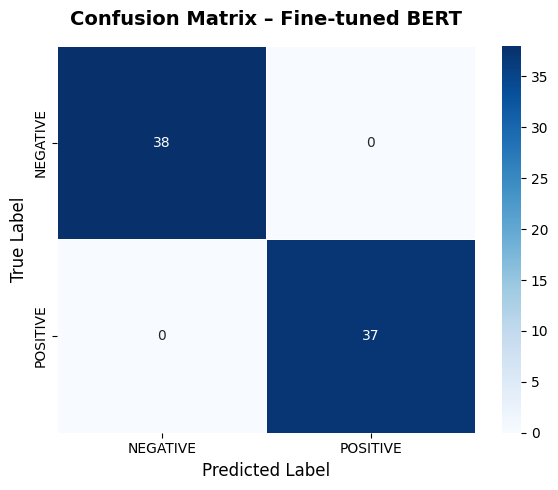


  True Negatives  (TN): 38
  False Positives (FP): 0
  False Negatives (FN): 0
  True Positives  (TP): 37


In [18]:
# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['NEGATIVE', 'POSITIVE'],
    yticklabels=['NEGATIVE', 'POSITIVE'],
    linewidths=0.5, ax=ax
)
ax.set_title('Confusion Matrix – Fine-tuned BERT', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives  (TP): {tp}")

In [19]:
# ── Compare Pre-trained Pipeline vs Fine-tuned BERT ──────────
comparison_sentences = X_test[:10]  # Use first 10 test samples
true_labels_comp     = [('POSITIVE' if l == 1 else 'NEGATIVE') for l in y_test[:10]]

# Pre-trained pipeline predictions
pretrained_results = sentiment_pipeline(comparison_sentences)
pretrained_labels  = [r['label'] for r in pretrained_results]
pretrained_scores  = [r['score'] for r in pretrained_results]

# Fine-tuned BERT predictions on same samples
mini_dataset = make_hf_dataset(comparison_sentences, [0]*10)  # dummy labels
ft_preds_output = trainer.predict(mini_dataset)
ft_pred_ids     = np.argmax(ft_preds_output.predictions, axis=-1)
ft_labels       = ['POSITIVE' if p == 1 else 'NEGATIVE' for p in ft_pred_ids]
ft_probs        = torch.softmax(torch.tensor(ft_preds_output.predictions), dim=-1).numpy()
ft_scores       = [ft_probs[i][ft_pred_ids[i]] for i in range(len(ft_pred_ids))]

# Comparison table
print("\n" + "="*90)
print(f"{'#':<3} {'True':<10} {'Pre-trained':^22} {'Fine-tuned':^22} {'Match'}")
print(f"{'':>3} {'Label':<10} {'Label':<12}{'Score':<10} {'Label':<12}{'Score':<10}")
print("="*90)
pretrained_correct, finetuned_correct = 0, 0
for i in range(10):
    true   = true_labels_comp[i]
    pre    = pretrained_labels[i]
    ft     = ft_labels[i]
    p_ok   = '✅' if pre == true else '❌'
    ft_ok  = '✅' if ft  == true else '❌'
    if pre == true: pretrained_correct += 1
    if ft  == true: finetuned_correct  += 1
    print(f"{i+1:<3} {true:<10} {pre:<12}{pretrained_scores[i]:.3f}     {ft:<12}{ft_scores[i]:.3f}     {p_ok} vs {ft_ok}")
print("="*90)
print(f"\n  Pre-trained Accuracy (10 samples): {pretrained_correct}/10 = {pretrained_correct*10}%")
print(f"  Fine-tuned  Accuracy (10 samples): {finetuned_correct}/10  = {finetuned_correct*10}%")

Map:   0%|          | 0/10 [00:00<?, ? examples/s]


#   True            Pre-trained             Fine-tuned       Match
    Label      Label       Score      Label       Score     
1   POSITIVE   POSITIVE    1.000     POSITIVE    0.779     ✅ vs ✅
2   POSITIVE   POSITIVE    1.000     POSITIVE    0.781     ✅ vs ✅
3   POSITIVE   POSITIVE    1.000     POSITIVE    0.801     ✅ vs ✅
4   POSITIVE   POSITIVE    1.000     POSITIVE    0.779     ✅ vs ✅
5   NEGATIVE   NEGATIVE    1.000     NEGATIVE    0.802     ✅ vs ✅
6   NEGATIVE   NEGATIVE    1.000     NEGATIVE    0.750     ✅ vs ✅
7   NEGATIVE   NEGATIVE    1.000     NEGATIVE    0.802     ✅ vs ✅
8   NEGATIVE   NEGATIVE    1.000     NEGATIVE    0.800     ✅ vs ✅
9   NEGATIVE   NEGATIVE    1.000     NEGATIVE    0.783     ✅ vs ✅
10  NEGATIVE   NEGATIVE    1.000     NEGATIVE    0.786     ✅ vs ✅

  Pre-trained Accuracy (10 samples): 10/10 = 100%
  Fine-tuned  Accuracy (10 samples): 10/10  = 100%


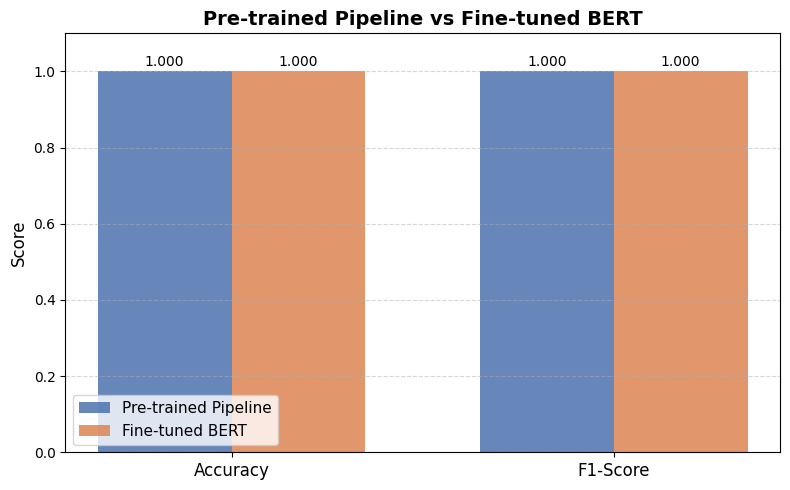


Pre-trained Pipeline — Accuracy: 1.0000 | F1: 1.0000
Fine-tuned BERT      — Accuracy: 1.0000 | F1: 1.0000


In [20]:
# ── Bar Chart: Model Comparison ───────────────────────────────
metrics = ['Accuracy', 'F1-Score']

# Re-evaluate pretrained pipeline on entire test set
pretrained_all = sentiment_pipeline(X_test, batch_size=32)
pretrained_preds = [1 if r['label'] == 'POSITIVE' else 0 for r in pretrained_all]

pre_acc = accuracy_score(y_test, pretrained_preds)
pre_f1  = f1_score(y_test, pretrained_preds, average='weighted')

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, [pre_acc, pre_f1],       width, label='Pre-trained Pipeline', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, [test_accuracy, test_f1], width, label='Fine-tuned BERT',      color='#DD8452', alpha=0.85)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Pre-trained Pipeline vs Fine-tuned BERT', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPre-trained Pipeline — Accuracy: {pre_acc:.4f} | F1: {pre_f1:.4f}")
print(f"Fine-tuned BERT      — Accuracy: {test_accuracy:.4f} | F1: {test_f1:.4f}")

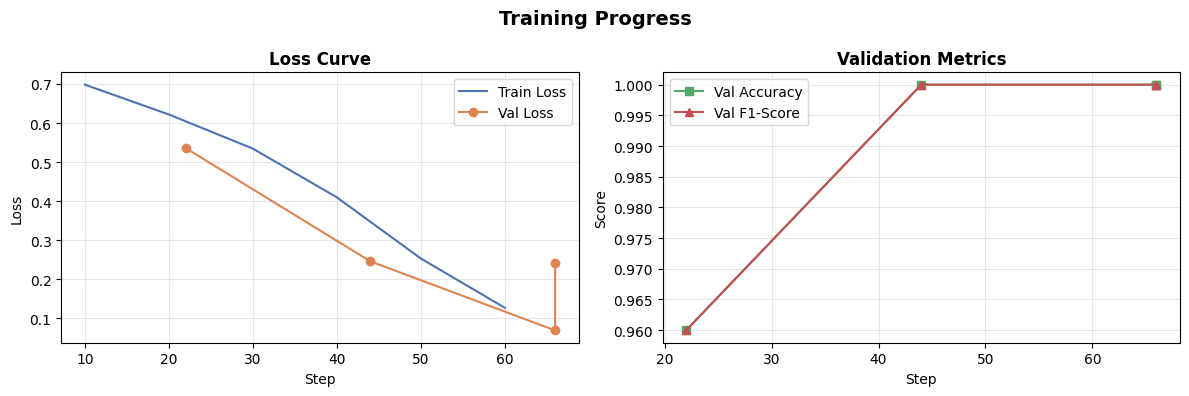

In [21]:
# ── Training Loss Curve ───────────────────────────────────────
log_history = trainer.state.log_history
train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_metrics = [(e['step'], e['eval_loss'], e['eval_accuracy'], e['eval_f1'])
                for e in log_history if 'eval_loss' in e]

if train_losses:
    steps_train, losses_train = zip(*train_losses)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(steps_train, losses_train, label='Train Loss', color='#4C72B0')
    if eval_metrics:
        steps_eval, eval_loss, eval_acc, eval_f1 = zip(*eval_metrics)
        axes[0].plot(steps_eval, eval_loss, 'o-', label='Val Loss', color='#DD8452')
    axes[0].set_title('Loss Curve', fontweight='bold')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy / F1
    if eval_metrics:
        axes[1].plot(steps_eval, eval_acc, 's-', label='Val Accuracy', color='#55A868')
        axes[1].plot(steps_eval, eval_f1, '^-',  label='Val F1-Score',  color='#C44E52')
        axes[1].set_title('Validation Metrics', fontweight='bold')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Score')
        axes[1].legend()
        axes[1].grid(alpha=0.3)

    plt.suptitle('Training Progress', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Training log not available (may occur in minimal training runs).")

In [22]:
# ── Short Explanation ─────────────────────────────────────────
explanation = """
╔══════════════════════════════════════════════════════════════════╗
║              Short Analysis – Part D                            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Why Transformers Outperform RNNs?                               ║
║  ──────────────────────────────────                               ║
║  1. Parallelism: RNNs process tokens sequentially, making them   ║
║     slow on long sequences. Transformers process ALL tokens      ║
║     simultaneously using self-attention, enabling much faster    ║
║     training on modern GPU/TPU hardware.                         ║
║                                                                  ║
║  2. Long-range dependencies: RNNs suffer from vanishing          ║
║     gradients, making it hard to capture context far apart in    ║
║     a sentence. Self-attention gives every token direct access   ║
║     to every other token regardless of distance — in one step.   ║
║                                                                  ║
║  3. Scalability: Transformers scale far better with data and     ║
║     model size (GPT, BERT, T5), outperforming RNNs across NLP   ║
║     benchmarks. Pre-training + fine-tuning also transfer well.   ║
║                                                                  ║
║  What is Self-Attention?                                         ║
║  ────────────────────────                                         ║
║  Self-attention is a mechanism that lets each token in a         ║
║  sequence attend to (focus on) every other token to compute      ║
║  a contextual representation. For each token, we compute         ║
║  three vectors: Query (Q), Key (K), and Value (V). The           ║
║  attention score = softmax(QKᵀ / √dₖ) × V, which weighs         ║
║  how relevant each token is to the current token. Multi-head     ║
║  attention runs this in parallel across multiple subspaces,      ║
║  allowing the model to capture diverse linguistic relationships   ║
║  (syntax, semantics, coreference) simultaneously in one layer.   ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(explanation)


╔══════════════════════════════════════════════════════════════════╗
║              Short Analysis – Part D                            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Why Transformers Outperform RNNs?                               ║
║  ──────────────────────────────────                               ║
║  1. Parallelism: RNNs process tokens sequentially, making them   ║
║     slow on long sequences. Transformers process ALL tokens      ║
║     simultaneously using self-attention, enabling much faster    ║
║     training on modern GPU/TPU hardware.                         ║
║                                                                  ║
║  2. Long-range dependencies: RNNs suffer from vanishing          ║
║     gradients, making it hard to capture context far apart in    ║
║     a sentence. Self-attention gives every token direct access   ║
║     to every other token regard

In [23]:
# ── Final Summary ─────────────────────────────────────────────
print("\n" + "="*55)
print("         📊 FINAL EVALUATION SUMMARY")
print("="*55)
print(f"  Model              : BERT-base-uncased (fine-tuned)")
print(f"  Dataset            : 500 movie reviews (balanced)")
print(f"  Max Sequence Length: {MAX_LENGTH} tokens")
print(f"  Training Epochs    : 3")
print(f"  Learning Rate      : 2e-5")
print(f"  Batch Size         : 16 (train) / 32 (eval)")
print("-"*55)
print(f"  ✅ Test Accuracy  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  ✅ Test F1-Score  : {test_f1:.4f}")
print(f"  ✅ Test Loss      : {test_loss:.4f}")
print("-"*55)
print(f"  Pre-trained Acc   : {pre_acc:.4f} ({pre_acc*100:.2f}%)")
print(f"  Pre-trained F1    : {pre_f1:.4f}")
print("="*55)
improvement = (test_accuracy - pre_acc) * 100
print(f"  📈 Fine-tuning improvement: {improvement:+.2f}%")
print("="*55)


         📊 FINAL EVALUATION SUMMARY
  Model              : BERT-base-uncased (fine-tuned)
  Dataset            : 500 movie reviews (balanced)
  Max Sequence Length: 128 tokens
  Training Epochs    : 3
  Learning Rate      : 2e-5
  Batch Size         : 16 (train) / 32 (eval)
-------------------------------------------------------
  ✅ Test Accuracy  : 1.0000 (100.00%)
  ✅ Test F1-Score  : 1.0000
  ✅ Test Loss      : 0.2419
-------------------------------------------------------
  Pre-trained Acc   : 1.0000 (100.00%)
  Pre-trained F1    : 1.0000
  📈 Fine-tuning improvement: +0.00%
